In [2]:
import pandas as pd
raw_data=pd.read_csv('telecom_churn_data.csv')
raw_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df=raw_data.copy()

# EDA

In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')



In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# بيانات العميل الشخصية (Demographics)

###                 first 5 col --> ID,gender,seniorcitizen,partner,dependents ---> handling whether mapping or drop

In [12]:
df.drop('customerID', axis=1, inplace=True)

In [14]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [15]:
df["gender"].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [16]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [17]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [18]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [20]:
df["Partner"] = df['Partner'].map({'Yes': 1, 'No': 0})

In [21]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,0,0,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [22]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [23]:
df["Dependents"] = df['Dependents'].map({'Yes': 1, 'No': 0})

In [24]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,0,0,0,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


# بيانات الحساب والتعاقد (Account Information)

### columns --> tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges 

In [25]:
df["tenure"].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

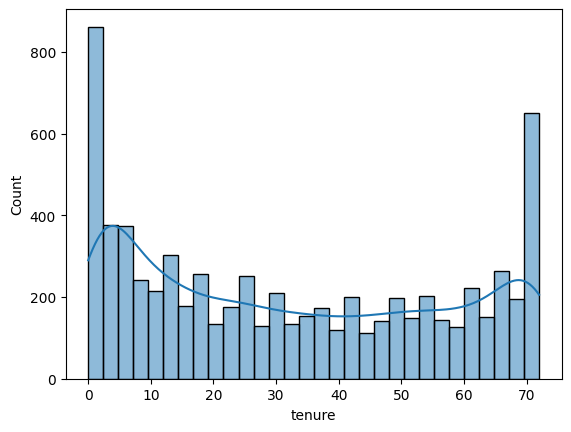

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='tenure', bins=30, kde=True)
plt.show()

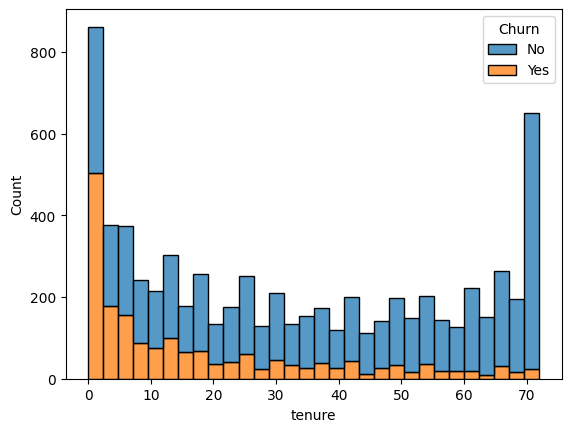

In [28]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.show()

In [29]:
def segment_tenure(df):
    bins = [0, 12, 24, 48, df['tenure'].max()]
    labels = ['New', 'Regular', 'Loyal', 'Super_Loyal']
    df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)
    return df

df = segment_tenure(df)

In [30]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,0,0,1,0,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New
1,1,0,0,0,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Loyal


In [31]:
df["tenure_group"].value_counts()

tenure_group
Super_Loyal    2239
New            2186
Loyal          1594
Regular        1024
Name: count, dtype: int64

In [32]:
encoding_dict = {
    'New': 0,
    'Regular': 1,
    'Loyal': 2,
    'Super_Loyal': 3
}

df['tenure_group'] = df['tenure_group'].map(encoding_dict)

In [39]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,0,0,1,0,1,No,No phone service,DSL,No,Yes,...,No,No,No,0,Yes,Electronic check,29.85,29.85,No,0
1,1,0,0,0,34,Yes,No,DSL,Yes,No,...,No,No,No,1,No,Mailed check,56.95,1889.50,No,2


In [37]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [38]:
contract_dict = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
df['Contract'] = df['Contract'].map(contract_dict)

In [42]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [43]:
df["PaperlessBilling"] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [44]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [45]:
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=True, dtype=int)

In [46]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_group,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,No,No phone service,DSL,No,Yes,...,No,0,1,29.85,29.85,No,0,0,1,0
1,1,0,0,0,34,Yes,No,DSL,Yes,No,...,No,1,0,56.95,1889.50,No,2,0,0,1


In [ ]:
df["MonthlyCharges"]

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
20.00     43
          ..
56.85      1
101.70     1
48.40      1
108.35     1
72.00      1
Name: count, Length: 1585, dtype: int64

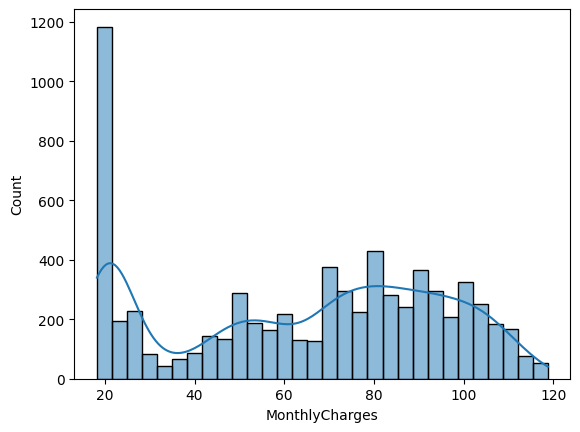

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='MonthlyCharges', bins=30, kde=True)
plt.show()

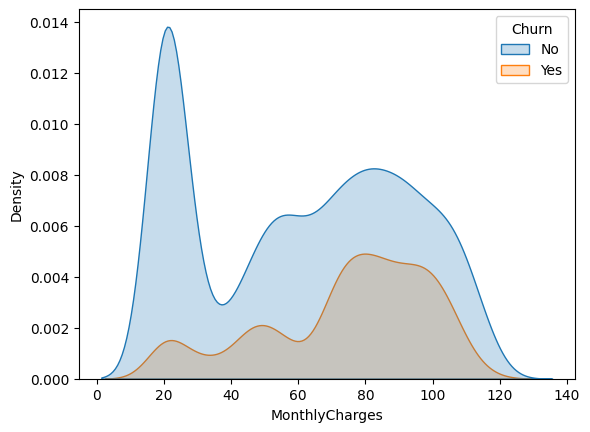

In [49]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.show()

In [50]:
df["TotalCharges"].value_counts()

TotalCharges
20.20      11
19.75       9
19.90       8
19.65       8
20.05       8
           ..
1990.50     1
7362.90     1
346.45      1
306.60      1
6844.50     1
Name: count, Length: 6530, dtype: int64

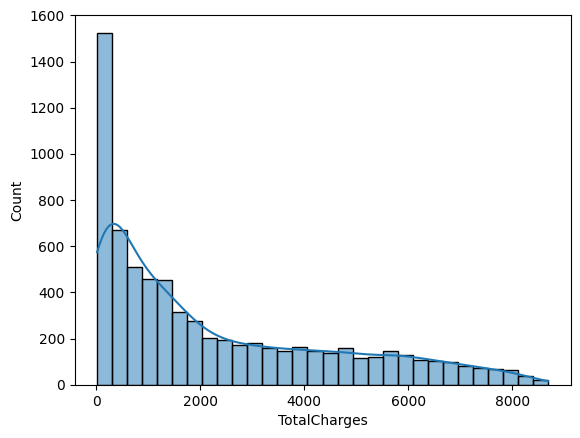

In [51]:
sns.histplot(data=df, x='TotalCharges', bins=30, kde=True)
plt.show()

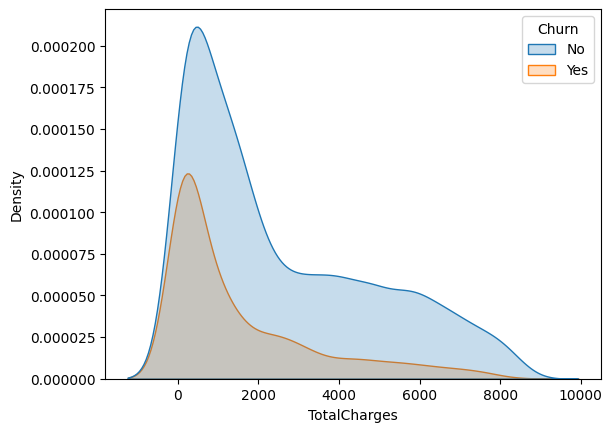

In [52]:
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True)
plt.show()

In [53]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [54]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [55]:
df["TotalCharges"].isnull().sum()

np.int64(0)

# الخدمات المشترك فيها العميل (Services)

### Handling data with mapping or hot encoding

In [56]:
df["PhoneService"]=df["PhoneService"].map({'Yes': 1, 'No': 0})

In [57]:
df["MultipleLines"]=df["MultipleLines"].map({'Yes': 1, 'No': 0, 'No phone service': 0})

In [58]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [59]:
df = pd.get_dummies(df, columns=['InternetService'], drop_first=True, dtype=int)

In [60]:
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df[services_cols] = df[services_cols].replace({'Yes': 1, 'No': 0, 'No internet service': 0})

C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_20728\2841068647.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[services_cols] = df[services_cols].replace({'Yes': 1, 'No': 0, 'No internet service': 0})


In [61]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_group,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,No,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,No,2,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,Yes,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,No,2,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,Yes,0,0,1,0,1,0


# Target

In [62]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [63]:
df["Churn"]=df["Churn"].map({'Yes': 1, 'No': 0})

In [64]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,tenure_group,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,2,0,0,1,0,0


# Feature engineering and handling outlayers

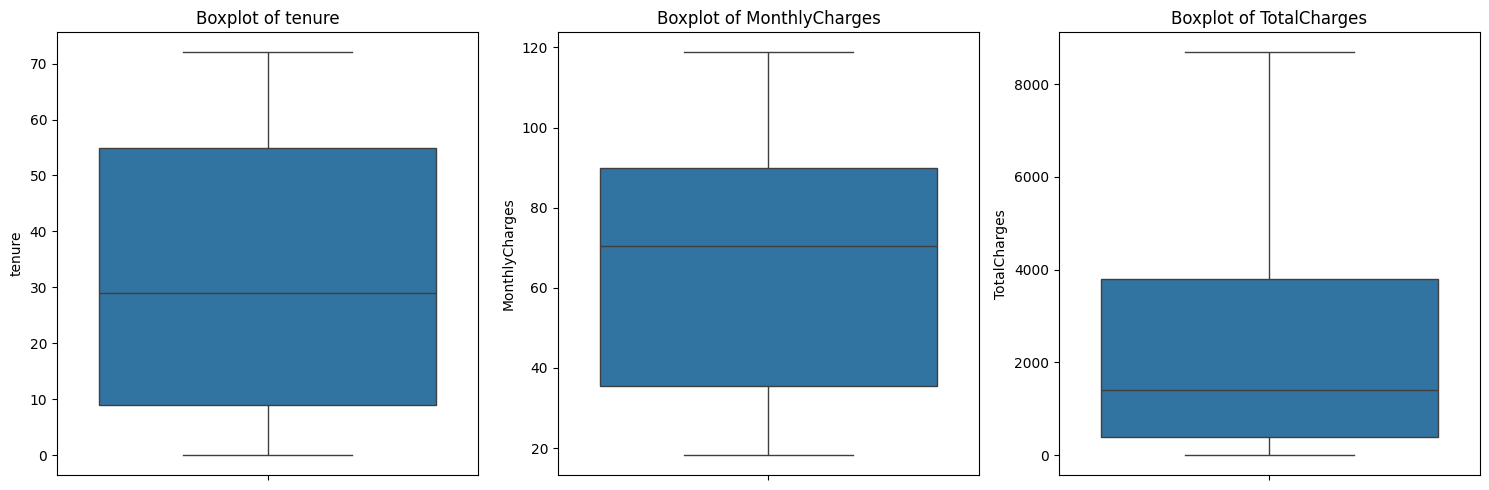

--- Number of Outliers in each column ---
tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

print("--- Number of Outliers in each column ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

In [69]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = df[services].sum(axis=1)

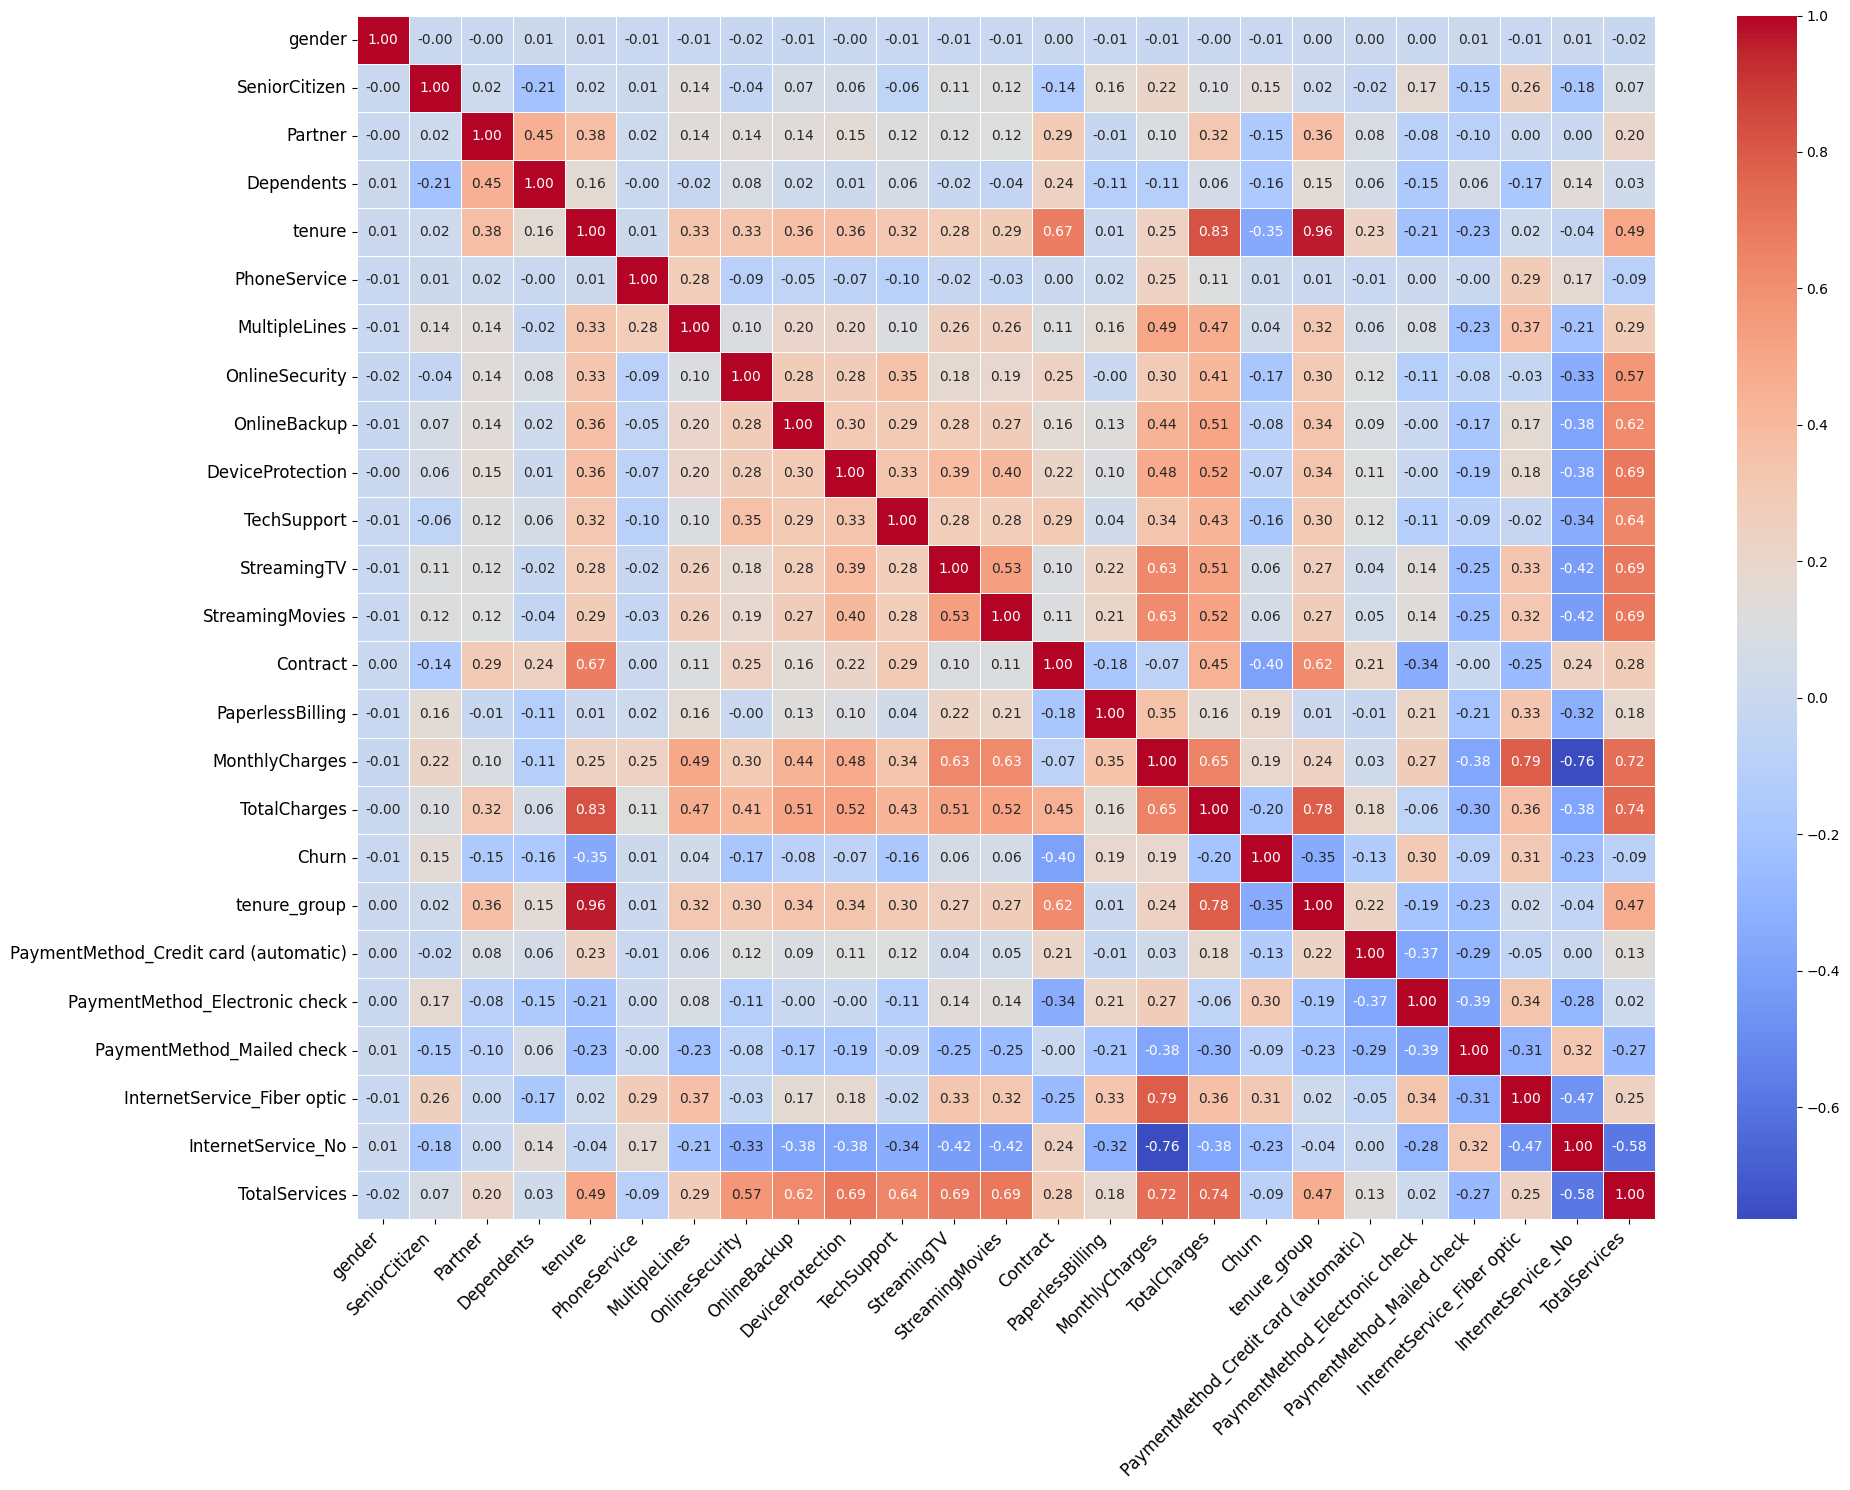

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(20, 15))

sns.heatmap(
    correlation_matrix, 
    annot=True,         
    fmt=".2f",          
    cmap='coolwarm',    
    linewidths=0.5,     
    annot_kws={"size": 10},
    xticklabels=correlation_matrix.columns,
    yticklabels=correlation_matrix.columns
)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('telecom_churn_heatmap.png', dpi=300)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

df['tenure_group'] = df['tenure_group'].astype(int)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

xgb_model = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print(f"{'Model':<20} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-" * 48)
print(f"{'Random Forest':<20} | {rf_acc:<10.4f} | {rf_f1:<10.4f}")
print(f"{'XGBoost':<20} | {xgb_acc:<10.4f} | {xgb_f1:<10.4f}")

print("\n" + "="*20 + " Random Forest Report " + "="*20)
print(classification_report(y_test, rf_pred))
print("="*20 + " XGBoost Report " + "="*20)
print(classification_report(y_test, xgb_pred))

Model                | Accuracy   | F1-Score  
------------------------------------------------
Random Forest        | 0.7878     | 0.5490    
XGBoost              | 0.7771     | 0.5514    

==================== Random Forest Report ====================
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

==================== XGBoost Report ====================
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"{'Model':<20} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-" * 48)
print(f"{'Random Forest':<20} | {rf_acc:<10.4f} | {rf_f1:<10.4f}")
print(f"{'XGBoost':<20} | {xgb_acc:<10.4f} | {xgb_f1:<10.4f}")
print(f"{'Decision Tree':<20} | {dt_acc:<10.4f} | {dt_f1:<10.4f}")

print("\n" + "="*20 + " Decision Tree Report " + "="*20)
print(classification_report(y_test, dt_pred))

Model                | Accuracy   | F1-Score  
------------------------------------------------
Random Forest        | 0.7878     | 0.5490    
XGBoost              | 0.7771     | 0.5514    
Decision Tree        | 0.7991     | 0.6064    

==================== Decision Tree Report ====================
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409



In [77]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"{'Model':<20} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-" * 48)
print(f"{'Random Forest':<20} | {rf_acc:<10.4f} | {rf_f1:<10.4f}")
print(f"{'XGBoost':<20} | {xgb_acc:<10.4f} | {xgb_f1:<10.4f}")
print(f"{'Decision Tree':<20} | {dt_acc:<10.4f} | {dt_f1:<10.4f}")
print(f"{'Logistic Regression':<20} | {lr_acc:<10.4f} | {lr_f1:<10.4f}")

print("\n" + "="*20 + " Logistic Regression Report " + "="*20)
print(classification_report(y_test, lr_pred))

Model                | Accuracy   | F1-Score  
------------------------------------------------
Random Forest        | 0.7878     | 0.5490    
XGBoost              | 0.7771     | 0.5514    
Decision Tree        | 0.7991     | 0.6064    
Logistic Regression  | 0.8034     | 0.5980    

==================== Logistic Regression Report ====================
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409

